In [53]:
!{sys.executable} -m pip install matplotlib seaborn

'{sys.executable}' nÆo ‚ reconhecido como um comando interno
ou externo, um programa oper vel ou um arquivo em lotes.


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

os.listdir("../data_sdr")

['.ipynb_checkpoints',
 'companies.csv',
 'leads.csv',
 'leads_por_cargo.csv',
 'leads_por_mes.csv',
 'leads_por_origem.csv',
 'leads_por_sdr.csv',
 'opportunities.csv',
 'sdrs.csv',
 'sdr_activity.csv',
 'touchpoints.csv']

In [54]:
import sys
print(sys.executable)


C:\Users\dvent\miniconda3\python.exe


In [56]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

In [ ]:
//Evita erros futuros, pois sempre irá direcionar os arquivos para os caminhos corretos. 

SyntaxError: invalid syntax (231408817.py, line 1)

In [79]:
# Detecta a pasta raiz do projeto (onde está a pasta data_sdr)
# Caminha a partir do notebook até encontrar "data_sdr"
def encontrar_data_path(start_dir="."):
    current_dir = os.path.abspath(start_dir)
    while True:
        potential_path = os.path.join(current_dir, "data_sdr")
        if os.path.isdir(potential_path):
            return potential_path
        # Sobe um nível
        parent_dir = os.path.dirname(current_dir)
        if parent_dir == current_dir:
            raise FileNotFoundError("Pasta 'data_sdr' não encontrada!")
        current_dir = parent_dir

data_path = encontrar_data_path()

print(f"Pasta de dados encontrada em: {data_path}")

# Carrega todos os CSVs na pasta data_sdr em DataFrames
dataframes = {}
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        name = file.replace(".csv", "")  # nome do DataFrame = nome do arquivo sem extensão
        dataframes[name] = pd.read_csv(os.path.join(data_path, file))
        print(f"Carregado: {file} → DataFrame '{name}' com {len(dataframes[name])} linhas")

# Acesso aos DataFrames
base_leads = dataframes.get("leads")
base_sdrs = dataframes.get("sdrs")
base_companies = dataframes.get("companies")

# Conferir primeiros registros
base_leads.head(), df_sdrs.head(), df_companies.head()


Pasta de dados encontrada em: C:\Users\dvent\OneDrive\Documentos\pipeline_sdr\data_sdr
Carregado: companies.csv → DataFrame 'companies' com 5000 linhas
Carregado: leads.csv → DataFrame 'leads' com 10000 linhas
Carregado: leads_por_cargo.csv → DataFrame 'leads_por_cargo' com 5 linhas
Carregado: leads_por_mes.csv → DataFrame 'leads_por_mes' com 24 linhas
Carregado: leads_por_origem.csv → DataFrame 'leads_por_origem' com 4 linhas
Carregado: leads_por_sdr.csv → DataFrame 'leads_por_sdr' com 8 linhas
Carregado: opportunities.csv → DataFrame 'opportunities' com 188 linhas
Carregado: sdrs.csv → DataFrame 'sdrs' com 8 linhas
Carregado: sdr_activity.csv → DataFrame 'sdr_activity' com 2920 linhas
Carregado: touchpoints.csv → DataFrame 'touchpoints' com 64485 linhas


NameError: name 'df_sdrs' is not defined

In [80]:
base_leads = pd.read_csv(
    r"C:\Users\dvent\OneDrive\Documentos\pipeline_sdr\data_sdr\leads.csv"
)

In [81]:
# Agrupa leads por SDR
leads_por_sdr = base_leads.groupby("sdr_owner")["lead_id"].count().reset_index()
leads_por_sdr.rename(columns={"lead_id": "total_leads"}, inplace=True)

print(leads_por_sdr)

   sdr_owner  total_leads
0          1         1244
1          2         1269
2          3         1277
3          4         1196
4          5         1230
5          6         1230
6          7         1300
7          8         1254


In [ ]:
os.getcwd()
# Mostra onde o notebook está sendo rodado

In [82]:
base_leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   lead_id     10000 non-null  int64 
 1   nome        10000 non-null  object
 2   email       10000 non-null  object
 3   cargo       10000 non-null  object
 4   empresa_id  10000 non-null  int64 
 5   origem      10000 non-null  object
 6   criado_em   10000 non-null  object
 7   sdr_owner   10000 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 625.1+ KB


In [83]:
base_leads.head(3)

,lead_id,nome,email,cargo,empresa_id,origem,criado_em,sdr_owner
0,1,Luiz Gustavo Cavalcante,rpacheco@example.net,CEO,4272,Eventos,2023-11-26,1
1,2,Maria Alice Fernandes,luiz-otaviooliveira@example.org,CTO,530,Outbound,2024-05-18,1
2,3,Clarice Correia,cda-luz@example.org,CEO,1160,Inbound,2023-07-29,3


In [84]:
base_leads.describe(include="all")

,lead_id,nome,email,cargo,empresa_id,origem,criado_em,sdr_owner
count,10000.00000,10000,10000,10000,10000.000000,10000,10000,10000.000000
unique,NaN,8893,9515,5,NaN,4,731,NaN
top,NaN,Marina Moraes,rcamara@example.org,Coordenador,NaN,Eventos,2023-04-13,NaN
freq,NaN,4,4,2046,NaN,2560,27,NaN
mean,5000.50000,NaN,NaN,NaN,2506.855400,NaN,NaN,4.505900
std,2886.89568,NaN,NaN,NaN,1452.328228,NaN,NaN,2.300194
min,1.00000,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000
25%,2500.75000,NaN,NaN,NaN,1244.000000,NaN,NaN,2.000000
50%,5000.50000,NaN,NaN,NaN,2508.000000,NaN,NaN,5.000000
75%,7500.25000,NaN,NaN,NaN,3760.250000,NaN,NaN,7.000000


In [85]:
# as datas estão em formatos diferentes, estão em formato object // feito conversão usando datetime para correção 
base_leads["criado_em"] = pd.to_datetime(base_leads["criado_em"])

In [86]:
base_leads["criado_em"].dt.month  # mês
base_leads["criado_em"].dt.weekday  # dia da semana

0       6
1       5
2       5
3       1
4       1
       ..
9995    0
9996    0
9997    2
9998    0
9999    1
Name: criado_em, Length: 10000, dtype: int32

In [87]:
#Convertendo sdr_owner para int64
base_leads["sdr_owner"] = base_leads["sdr_owner"].astype(int)

In [88]:
base_leads["sdr_owner"].unique()

array([1, 3, 2, 4, 5, 7, 8, 6])

In [89]:
# Início 
# Configuração visual
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [90]:
# Garantir tipos corretos
base_leads["criado_em"] = pd.to_datetime(base_leads["criado_em"])
base_leads["lead_id"] = base_leads["lead_id"].astype(int)
base_leads["empresa_id"] = base_leads["empresa_id"].astype(int)
base_leads["sdr_owner"] = base_leads["sdr_owner"].astype(int)

In [91]:
# 3. Informações gerais
print("Informações do dataset:")
display(base_leads.info())

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   lead_id     10000 non-null  int64         
 1   nome        10000 non-null  object        
 2   email       10000 non-null  object        
 3   cargo       10000 non-null  object        
 4   empresa_id  10000 non-null  int64         
 5   origem      10000 non-null  object        
 6   criado_em   10000 non-null  datetime64[ns]
 7   sdr_owner   10000 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 625.1+ KB


None

In [92]:
print("\nEstatísticas descritivas:")
display(base_leads.describe(include="all"))


Estatísticas descritivas:


,lead_id,nome,email,cargo,empresa_id,origem,criado_em,sdr_owner
count,10000.00000,10000,10000,10000,10000.000000,10000,10000,10000.000000
unique,NaN,8893,9515,5,NaN,4,NaN,NaN
top,NaN,Marina Moraes,rcamara@example.org,Coordenador,NaN,Eventos,NaN,NaN
freq,NaN,4,4,2046,NaN,2560,NaN,NaN
mean,5000.50000,NaN,NaN,NaN,2506.855400,NaN,2023-12-30 22:38:47.040000,4.505900
min,1.00000,NaN,NaN,NaN,1.000000,NaN,2023-01-01 00:00:00,1.000000
25%,2500.75000,NaN,NaN,NaN,1244.000000,NaN,2023-07-04 00:00:00,2.000000
50%,5000.50000,NaN,NaN,NaN,2508.000000,NaN,2024-01-01 00:00:00,5.000000
75%,7500.25000,NaN,NaN,NaN,3760.250000,NaN,2024-06-29 00:00:00,7.000000
max,10000.00000,NaN,NaN,NaN,5000.000000,NaN,2024-12-31 00:00:00,8.000000


In [70]:
print("\nPrimeiras 5 linhas:")
display(base_leads.head())


Primeiras 5 linhas:


,lead_id,nome,email,cargo,empresa_id,origem,criado_em,sdr_owner
0,1,Luiz Gustavo Cavalcante,rpacheco@example.net,CEO,4272,Eventos,2023-11-26,1
1,2,Maria Alice Fernandes,luiz-otaviooliveira@example.org,CTO,530,Outbound,2024-05-18,1
2,3,Clarice Correia,cda-luz@example.org,CEO,1160,Inbound,2023-07-29,3
3,4,Anna Liz Ferreira,wda-conceicao@example.com,CEO,4855,Outbound,2024-07-16,2
4,5,Gabrielly Marques,ribeirojoao-miguel@example.net,Gerente,3492,Outbound,2024-04-23,4



Leads por SDR:


,sdr_owner,total_leads
0,1,1244
1,2,1269
2,3,1277
3,4,1196
4,5,1230
5,6,1230
6,7,1300
7,8,1254


C:\Users\dvent\AppData\Local\Temp\ipykernel_27680\3764629078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="sdr_owner", y="total_leads", data=leads_por_sdr, palette="Blues_d")


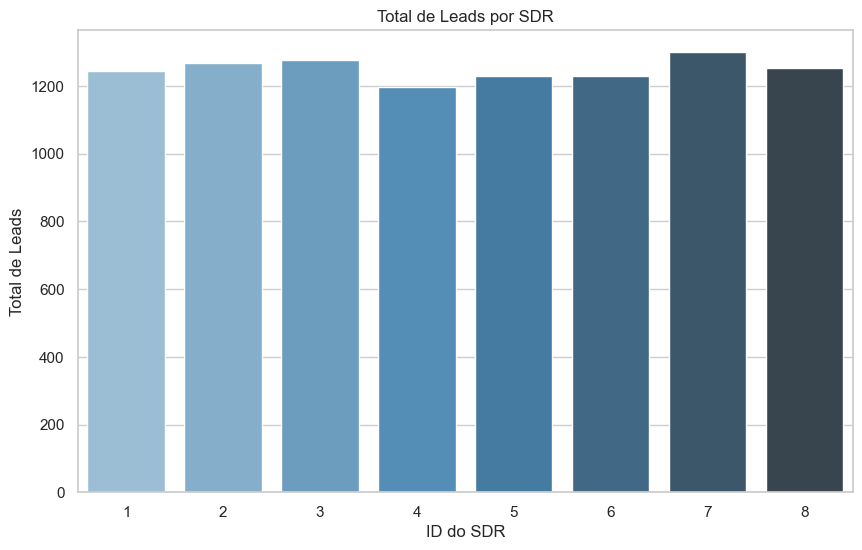

In [93]:
#Agrupamento por SDR
leads_por_sdr = base_leads.groupby("sdr_owner")["lead_id"].count().reset_index()
leads_por_sdr.rename(columns={"lead_id": "total_leads"}, inplace=True)
print("\nLeads por SDR:")
display(leads_por_sdr)

sns.barplot(x="sdr_owner", y="total_leads", data=leads_por_sdr, palette="Blues_d")
plt.title("Total de Leads por SDR")
plt.xlabel("ID do SDR")
plt.ylabel("Total de Leads")
plt.show()


Leads por origem:


,origem,total
0,Eventos,2560
1,Outbound,2506
2,Indicação,2477
3,Inbound,2457


C:\Users\dvent\AppData\Local\Temp\ipykernel_27680\2932059277.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="origem", y="total", data=leads_por_origem, palette="Greens_d")


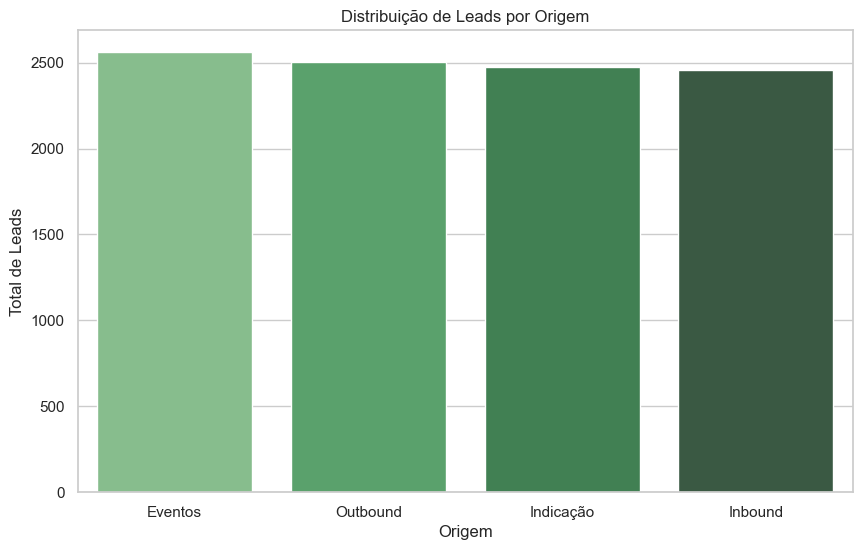

In [94]:
#Distribuição por origem
leads_por_origem = base_leads["origem"].value_counts().reset_index()
leads_por_origem.columns = ["origem", "total"]

print("\nLeads por origem:")
display(leads_por_origem)

sns.barplot(x="origem", y="total", data=leads_por_origem, palette="Greens_d")
plt.title("Distribuição de Leads por Origem")
plt.xlabel("Origem")
plt.ylabel("Total de Leads")
plt.show()


Leads por cargo:


,cargo,total
0,Coordenador,2046
1,CTO,2000
2,Analista,2000
3,Gerente,1979
4,CEO,1975


C:\Users\dvent\AppData\Local\Temp\ipykernel_27680\846722546.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="cargo", y="total", data=leads_por_cargo, palette="Oranges_d")


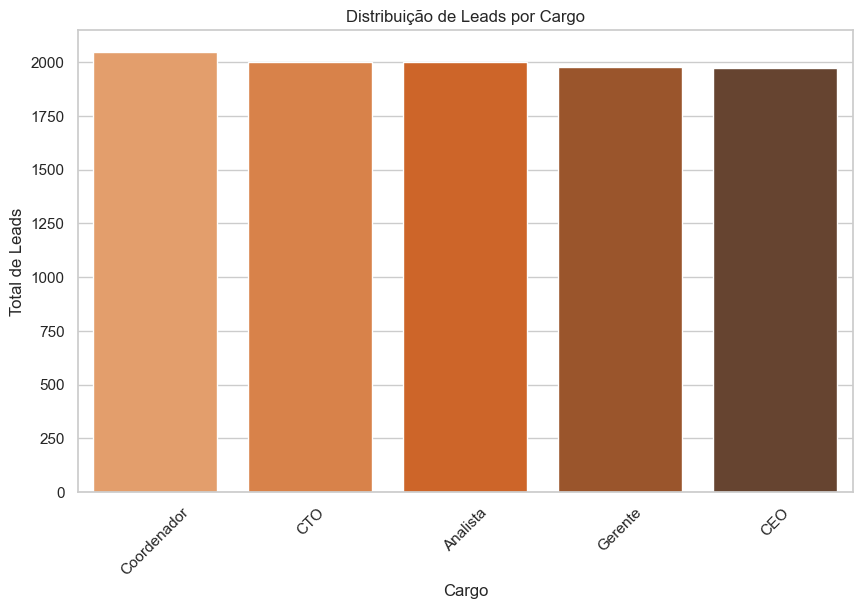

In [95]:
#Distribuição por cargo
leads_por_cargo = base_leads["cargo"].value_counts().reset_index()
leads_por_cargo.columns = ["cargo", "total"]

print("\nLeads por cargo:")
display(leads_por_cargo)

sns.barplot(x="cargo", y="total", data=leads_por_cargo, palette="Oranges_d")
plt.title("Distribuição de Leads por Cargo")
plt.xlabel("Cargo")
plt.ylabel("Total de Leads")
plt.xticks(rotation=45)
plt.show()